#Introduction

MRI acquisition time is determined by the number of phase-encoding lines sampled in k-space. Cartesian undersampling reduces scan time by acquiring only a subset of k-space, but this acceleration comes at the cost of image artifacts. This investigation examines the relationship between undersampling, acceleration factor, and reconstruction quality using uniform Cartesian sampling.

In [ ]:
# Import the phantom generator
from src.phantom import generate_shepp_logan

# Import image visualization utilities
from src.image_utils import (
    display_image,
    compare_images
)

# Import Fourier Transform utilities
from src.fft import (
    fft2c,
    ifft2c,
    magnitude
)

# Import k-space visualization utility
from src.kspace import (
    log_magnitude
)

# Import Cartesian MRI sampling utilities
from src.cartesian_sampling import (
    create_full_mask,
    create_cartesian_mask,
    apply_sampling_mask,
    sampling_percentage,
    acceleration_factor
)

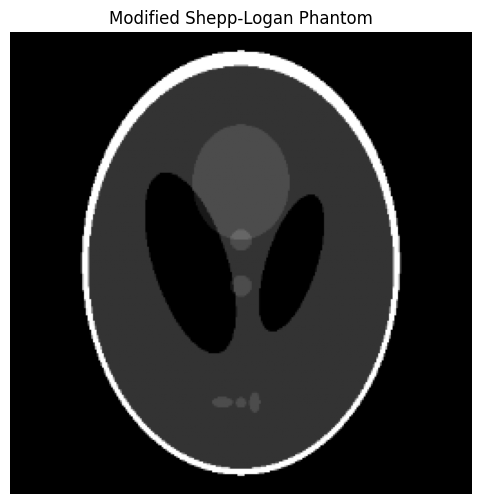

In [ ]:
# Generate the Modified Shepp–Logan phantom.
# This phantom serves as the object to be imaged
# throughout the reconstruction experiments.
phantom = generate_shepp_logan(size=256)

# Display the phantom in image space.
display_image(
    image=phantom,
    title="Modified Shepp-Logan Phantom"
)

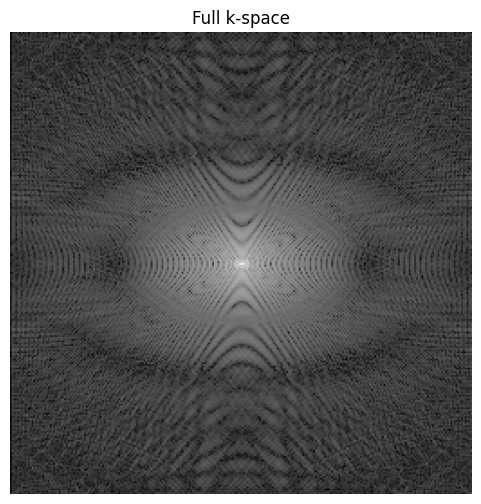

In [ ]:
# Transform the phantom from image space to k-space
# using the centered two-dimensional Fourier Transform.
kspace = fft2c(phantom)

# Display the log-scaled magnitude of k-space.
# Log scaling is used because the center of k-space
# has a much higher intensity than the outer regions.
display_image(
    image=log_magnitude(kspace),
    title="Full k-space"
)

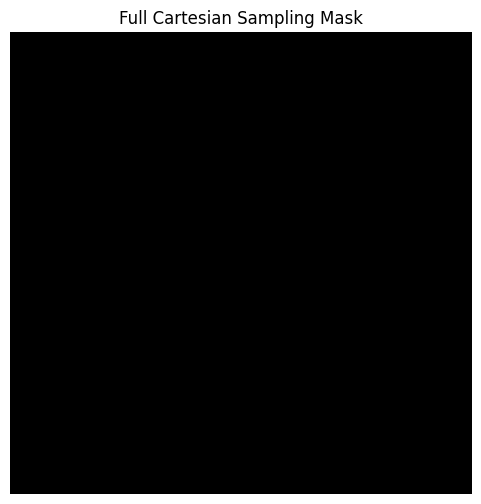

In [ ]:
# Create a sampling mask containing only ones.
# This represents a fully sampled MRI acquisition,
# where every k-space location is acquired.
full_mask = create_full_mask(kspace.shape)

# Display the full sampling mask.
display_image(
    image=full_mask,
    title="Full Cartesian Sampling Mask"
)

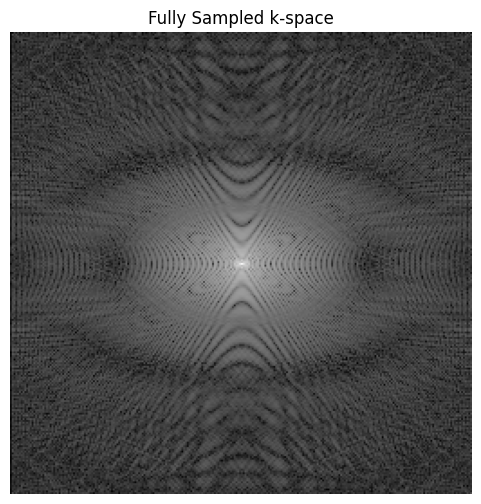

In [ ]:
# Apply the full sampling mask to k-space.
# Since every location is sampled, the resulting
# k-space is identical to the original k-space.
fully_sampled_kspace = apply_sampling_mask(
    kspace,
    full_mask
)

# Display the fully sampled k-space.
display_image(
    image=log_magnitude(fully_sampled_kspace),
    title="Fully Sampled k-space"
)

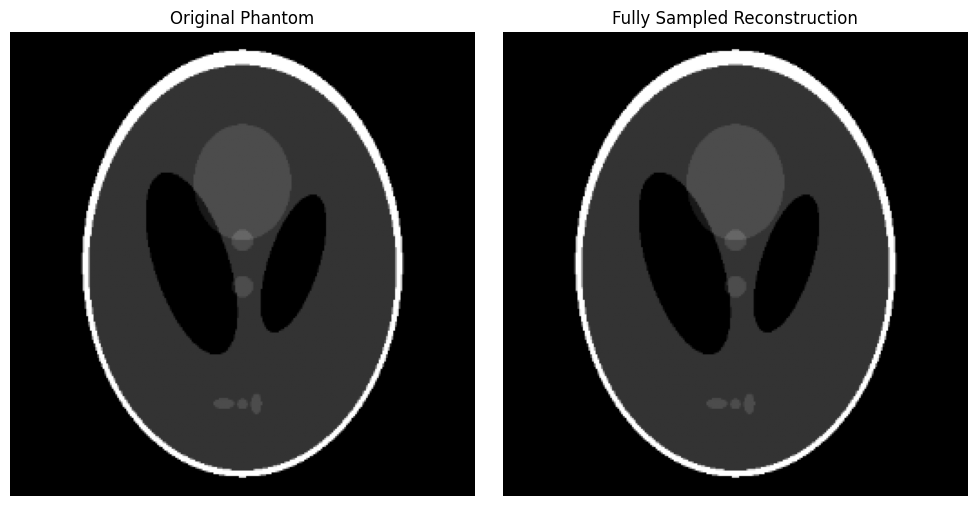

In [ ]:
# Reconstruct the image from the fully sampled k-space
# using the inverse Fourier Transform.
fully_sampled_image = magnitude(
    ifft2c(fully_sampled_kspace)
)

# Compare the original phantom with the reconstructed image.
# Since no data were removed, the reconstruction should
# closely match the original phantom.
compare_images(
    image1=phantom,
    image2=fully_sampled_image,
    title1="Original Phantom",
    title2="Fully Sampled Reconstruction"
)

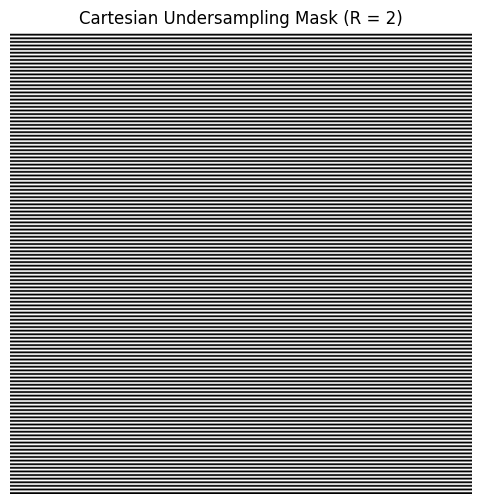

In [ ]:
# Create a Cartesian undersampling mask with an
# acceleration factor of 2.
#
# Every second phase-encoding line is acquired,
# while the remaining lines are skipped.
cartesian_mask = create_cartesian_mask(
    shape=kspace.shape,
    acceleration=2
)

# Display the Cartesian sampling mask.
display_image(
    image=cartesian_mask,
    title="Cartesian Undersampling Mask (R = 2)"
)

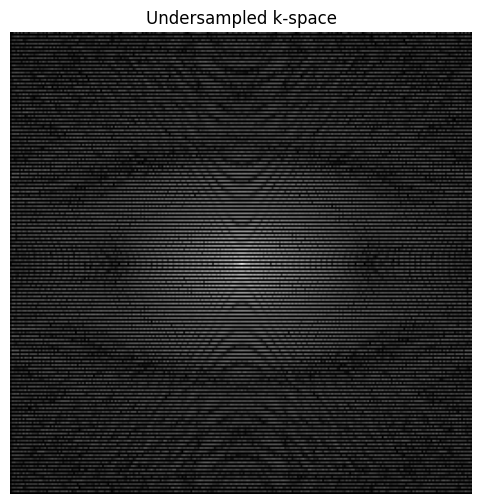

In [ ]:
# Apply the Cartesian undersampling mask to k-space.
# The skipped phase-encoding lines are replaced with zeros,
# simulating accelerated MRI acquisition.
undersampled_kspace = apply_sampling_mask(
    kspace,
    cartesian_mask
)

# Display the undersampled k-space.
display_image(
    image=log_magnitude(undersampled_kspace),
    title="Undersampled k-space"
)

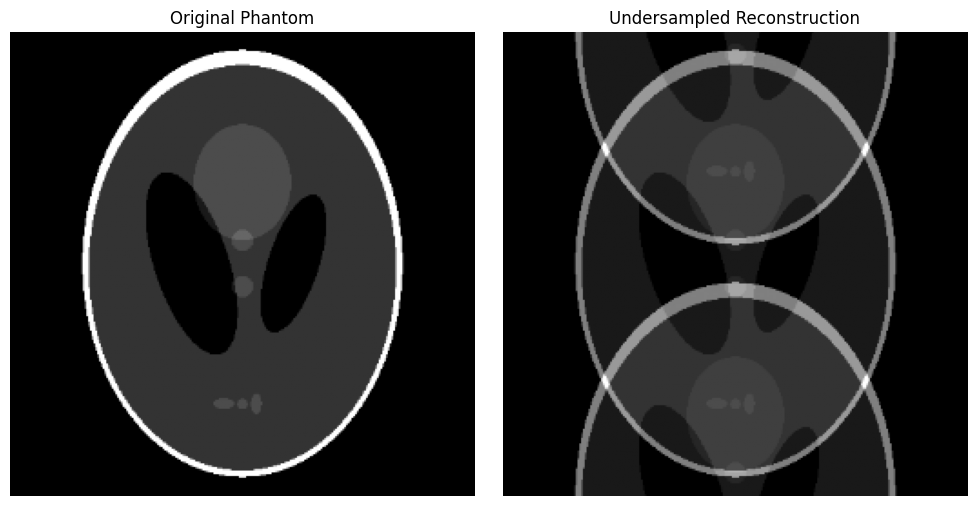

In [ ]:
# Reconstruct the image from the undersampled k-space.
# Missing k-space lines lead to aliasing artifacts
# in the reconstructed image.
undersampled_image = magnitude(
    ifft2c(undersampled_kspace)
)

# Compare the original phantom with the undersampled reconstruction.
# Observe the effect of Cartesian undersampling on image quality.
compare_images(
    image1=phantom,
    image2=undersampled_image,
    title1="Original Phantom",
    title2="Undersampled Reconstruction"
)

In [ ]:
# Calculate and display the percentage of k-space
# that was acquired during the simulated MRI scan.
print(f"Sampling Percentage : {sampling_percentage(cartesian_mask):.2f}%")

# Calculate and display the corresponding acceleration factor.
# A higher acceleration factor indicates a faster acquisition
# but generally results in increased reconstruction artifacts.
print(f"Acceleration Factor : R = {acceleration_factor(cartesian_mask):.2f}")

Sampling Percentage : 50.00%
Acceleration Factor : R = 2.00


In [ ]:
# ============================================================
# Experiment: Effect of Acceleration Factor on Image Quality
# ============================================================

In [ ]:
# Define the acceleration factors to investigate.
# Higher acceleration means fewer acquired phase-encoding lines
# and therefore a faster MRI acquisition.
acceleration_factors = [2, 4, 8]

Acceleration Factor: R = 2


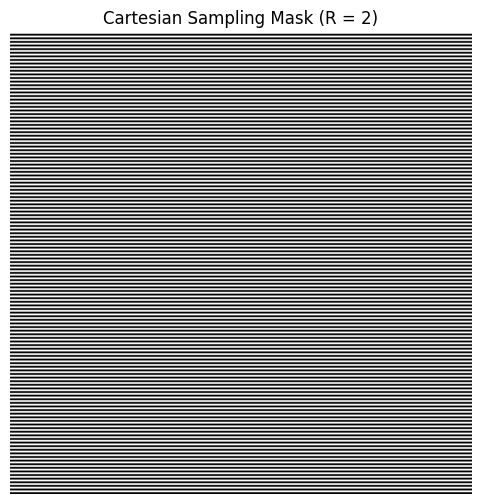

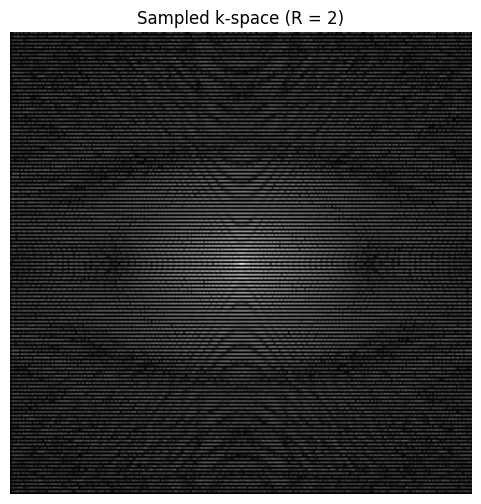

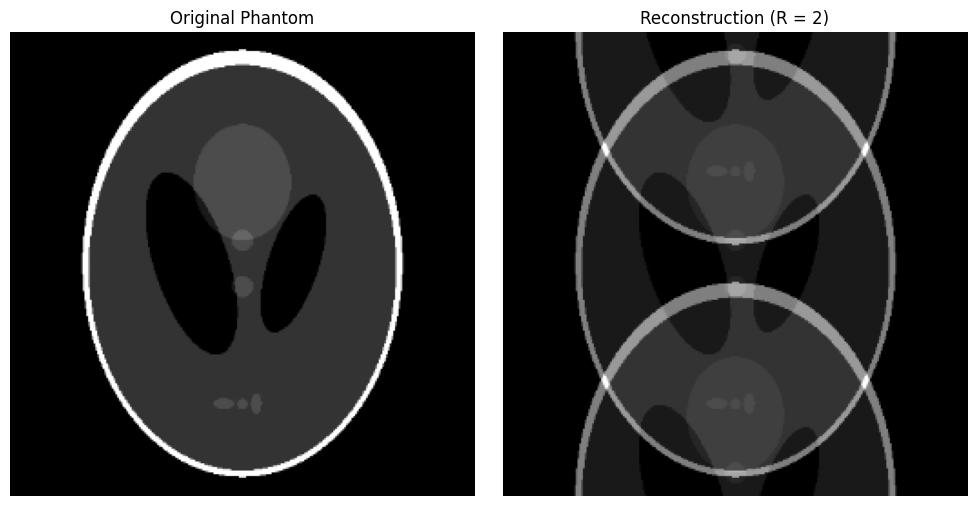

Sampling Percentage : 50.00%
Acceleration Factor : 2.00
Acceleration Factor: R = 4


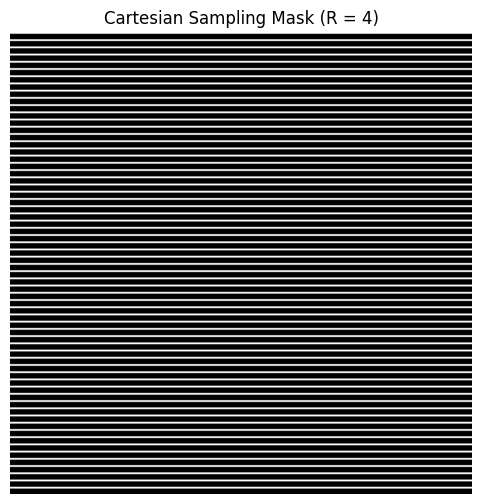

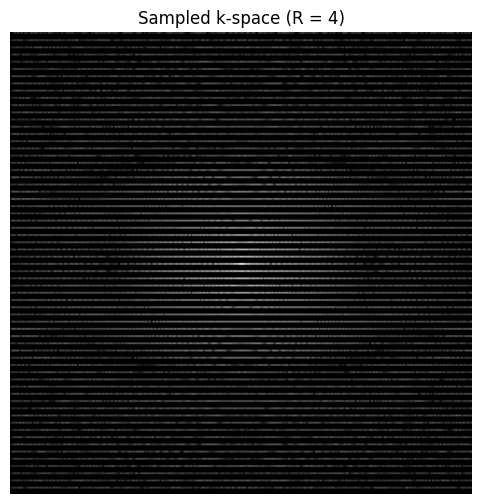

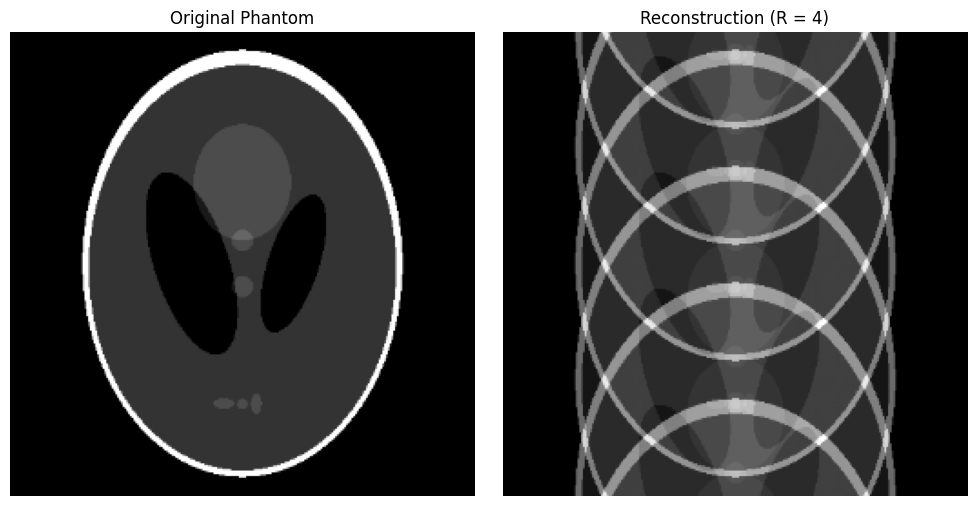

Sampling Percentage : 25.00%
Acceleration Factor : 4.00
Acceleration Factor: R = 8


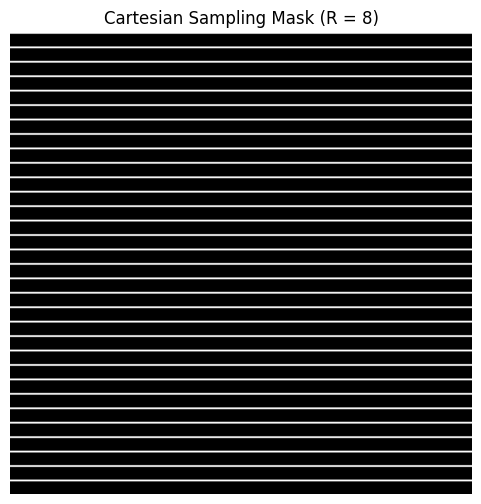

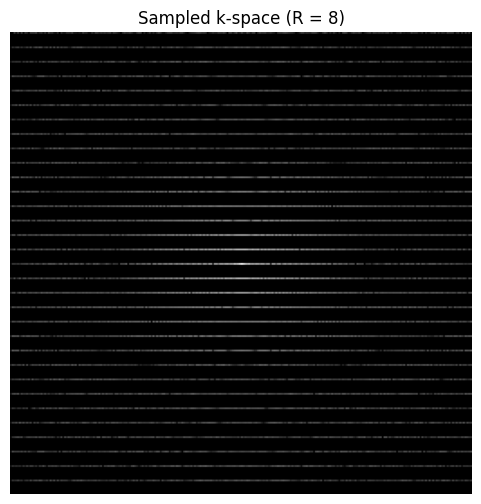

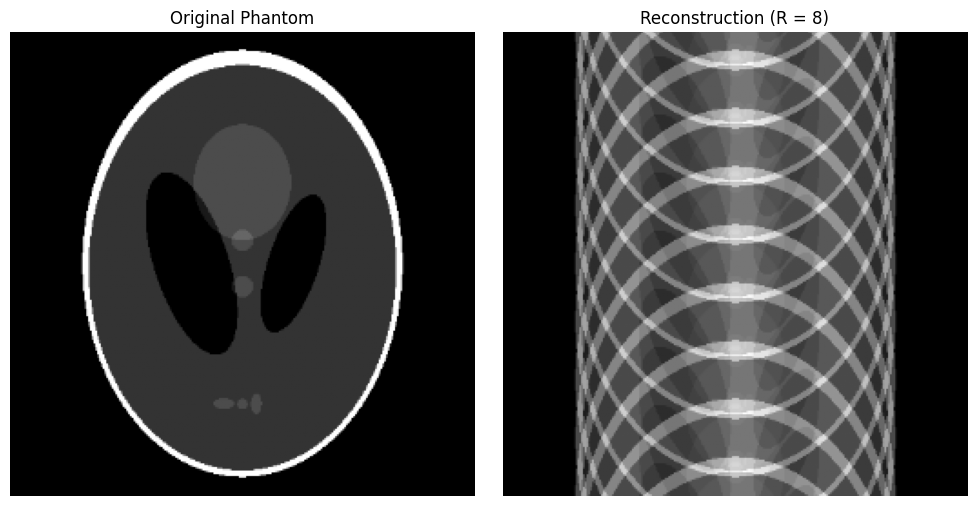

Sampling Percentage : 12.50%
Acceleration Factor : 8.00


In [ ]:
# Evaluate the effect of different acceleration factors
# on the reconstructed image.

for R in acceleration_factors:

    print("=" * 60)
    print(f"Acceleration Factor: R = {R}")
    print("=" * 60)

    # Create a Cartesian undersampling mask
    mask = create_cartesian_mask(
        shape=kspace.shape,
        acceleration=R
    )

    # Display the sampling mask
    display_image(
        image=mask,
        title=f"Cartesian Sampling Mask (R = {R})"
    )

    # Apply the sampling mask
    sampled_kspace = apply_sampling_mask(
        kspace,
        mask
    )

    # Display the sampled k-space
    display_image(
        image=log_magnitude(sampled_kspace),
        title=f"Sampled k-space (R = {R})"
    )

    # Reconstruct the image
    reconstructed = magnitude(
        ifft2c(sampled_kspace)
    )

    # Compare with the original phantom
    compare_images(
        image1=phantom,
        image2=reconstructed,
        title1="Original Phantom",
        title2=f"Reconstruction (R = {R})"
    )

    # Display acquisition statistics
    print(f"Sampling Percentage : {sampling_percentage(mask):.2f}%")
    print(f"Acceleration Factor : {acceleration_factor(mask):.2f}")

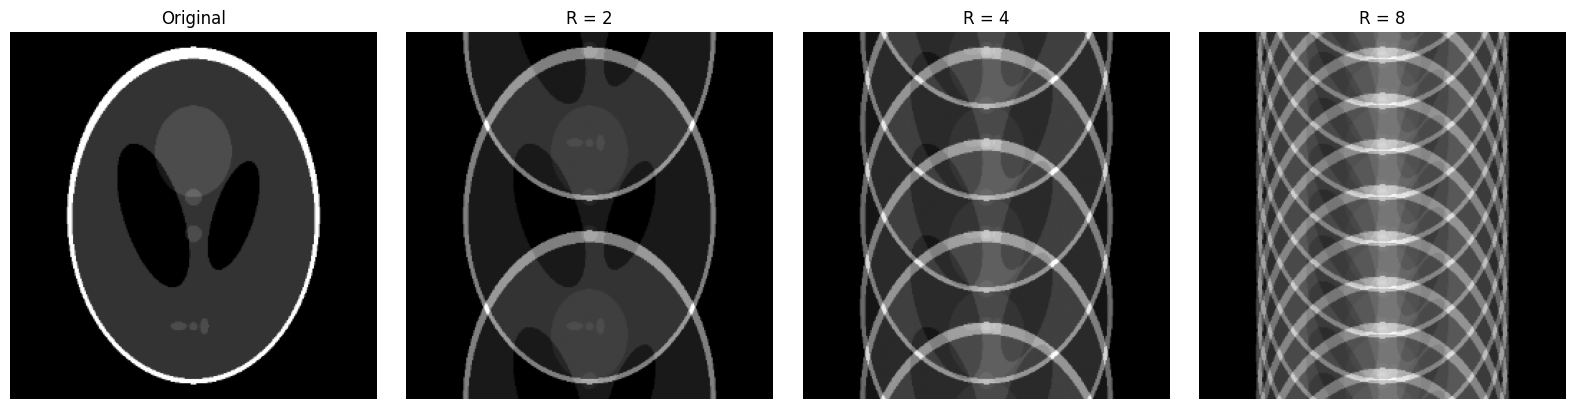

In [ ]:
import matplotlib.pyplot as plt

# Compare reconstructions obtained with different
# acceleration factors.

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

axes[0].imshow(phantom, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, R in zip(axes[1:], acceleration_factors):

    mask = create_cartesian_mask(
        shape=kspace.shape,
        acceleration=R
    )

    sampled = apply_sampling_mask(
        kspace,
        mask
    )

    recon = magnitude(
        ifft2c(sampled)
    )

    ax.imshow(recon, cmap="gray")
    ax.set_title(f"R = {R}")
    ax.axis("off")

plt.tight_layout()
plt.show()

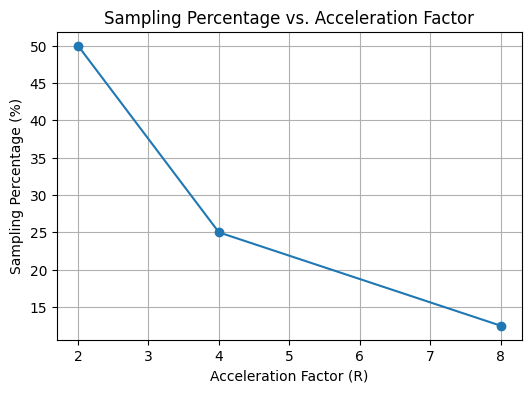

In [ ]:
import matplotlib.pyplot as plt

sampling = []

for R in acceleration_factors:

    mask = create_cartesian_mask(
        shape=kspace.shape,
        acceleration=R
    )

    sampling.append(
        sampling_percentage(mask)
    )

plt.figure(figsize=(6, 4))
plt.plot(acceleration_factors, sampling, marker="o")
plt.xlabel("Acceleration Factor (R)")
plt.ylabel("Sampling Percentage (%)")
plt.title("Sampling Percentage vs. Acceleration Factor")
plt.grid(True)
plt.show()

## Discussion

This investigation examined the effect of Cartesian k-space undersampling on MRI image reconstruction. A fully sampled acquisition preserves all spatial frequency information, enabling accurate reconstruction of the original image through the inverse Fourier Transform. In contrast, uniform Cartesian undersampling removes phase-encoding lines to reduce acquisition time, resulting in incomplete k-space measurements.

As the acceleration factor increases, the sampling percentage decreases, leading to progressively stronger aliasing artifacts and degradation of image quality. These results illustrate the fundamental trade-off between acquisition speed and reconstruction fidelity in accelerated MRI. While conventional inverse Fourier reconstruction accurately reconstructs fully sampled data, it cannot recover information lost through undersampling. This limitation motivates the development of advanced reconstruction techniques, such as parallel imaging, compressed sensing, and deep learning, which exploit additional information to recover high-quality images from incomplete k-space data.